Загрузка данных...
Файлы загружены. Гипнограмма: 17550 сек. События: 25 строк.
Нанесено событий: 25


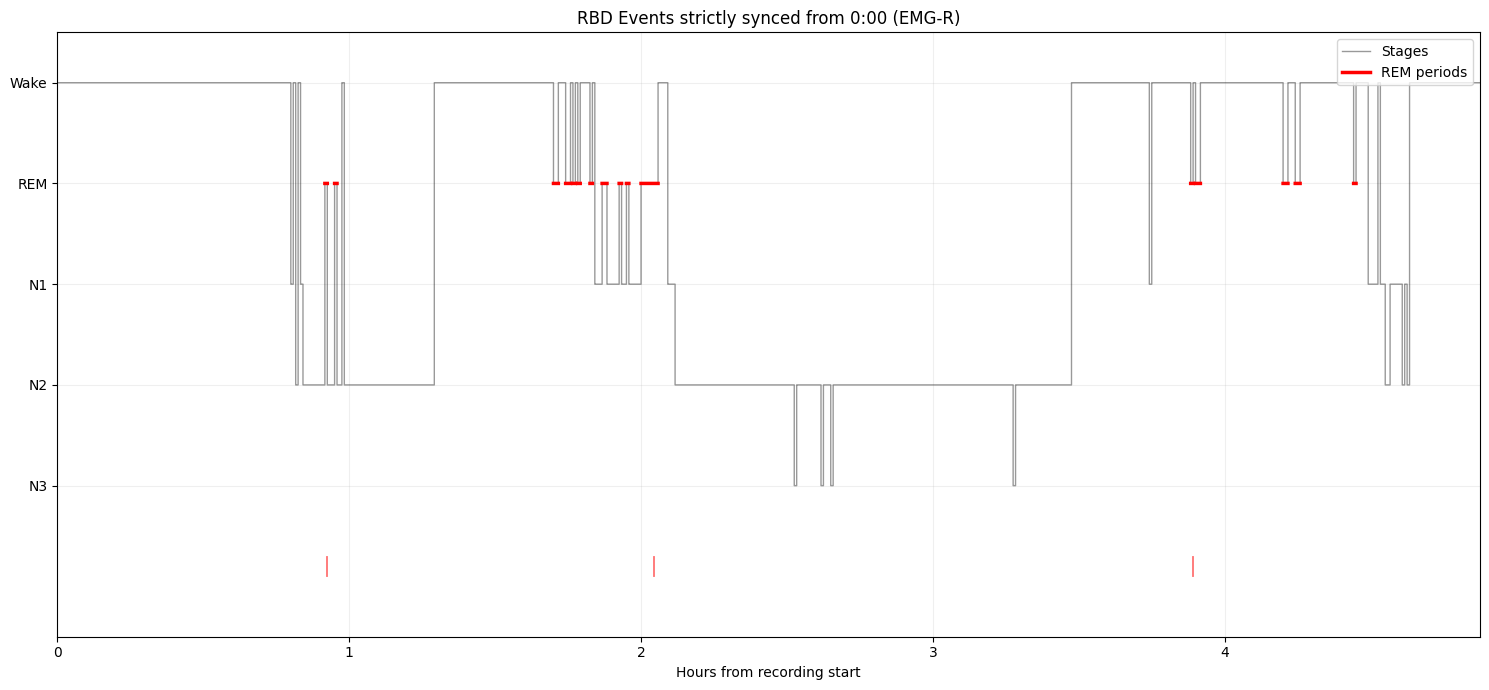

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# ==================== НАСТРОЙКИ ПУТЕЙ ====================
# Укажи свои пути к файлам
HYPNO_PATH = r"D:\PD_MFF\PB24_sleep_20251116_121109_spectral\hypno_point_per_row_1hz_numeric.txt"
EVENTS_PATH = r"D:\PD_MFF\PB24_sleep_20251116_121109_spectral\rbdtector_case\RBDtector output\RBDtection_Events_RBDtector output.csv"
SIGNAL_NAME = "EMG-R"
# =========================================================

def plot_standalone_rbd():
    print("Загрузка данных...")
    try:
        # 1. Загрузка гипнограммы (1 секунда на строку)
        hypno = np.loadtxt(HYPNO_PATH, dtype=int)
        # 2. Загрузка событий (разделитель запятая, заголовков нет)
        events_df = pd.read_csv(EVENTS_PATH, header=None, engine='python')
        print(f"Файлы загружены. Гипнограмма: {len(hypno)} сек. События: {len(events_df)} строк.")
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        return

    # ПОДГОТОВКА ГРАФИКА
    t_hours = np.arange(len(hypno)) / 3600.0
    # Маппинг для Y-оси: Wake=0, REM=-1, N1=-2, N2=-3, N3=-4
    mapping = {0: 0, 4: -1, 1: -2, 2: -3, 3: -4}
    y_hypno = pd.Series(hypno).map(mapping).fillna(-4).to_numpy()

    plt.figure(figsize=(15, 7))
    
    # Рисуем основную линию "лестницей"
    plt.step(t_hours, y_hypno, where='post', color='black', linewidth=1, alpha=0.4, label='Stages')

    # Выделяем REM (код 4) красным цветом прямо на линии графика
    rem_line = np.ma.masked_where(hypno != 4, y_hypno)
    plt.step(t_hours, rem_line, where='post', color='red', linewidth=2.5, label='REM periods')

    # ОТРИСОВКА СОБЫТИЙ (СИНХРОНИЗАЦИЯ ОТ 00:00:00)
    # Так как meas_date был None, RBDtector считает старт записи как 1985-01-01 00:00:00
    base_zero = pd.Timestamp("1985-01-01 00:00:00")
    clean_sig = SIGNAL_NAME.replace("-", "").upper()
    found = 0

    for _, row in events_df.iterrows():
        if len(row) < 3: continue
        label = str(row[2]).replace("-","").upper()
        
        if clean_sig in label:
            # Время события из CSV (например, 1985-01-01 04:06:49)
            start_ev = pd.to_datetime(row[0])
            end_ev = pd.to_datetime(row[1])
            
            # Считаем чистый сдвиг в часах от начала (от 00:00:00)
            sh = (start_ev - base_zero).total_seconds() / 3600.0
            eh = (end_ev - base_zero).total_seconds() / 3600.0

            # Рисуем МАКСИМАЛЬНО ЖИРНЫЙ красный блок под графиком (уровень -4.7)
            if eh > 0 and sh < t_hours[-1]:
                plt.hlines(y=-4.8, xmin=sh, xmax=eh, color='red', linewidth=15)
                found += 1

    print(f"Нанесено событий: {found}")

    # ОФОРМЛЕНИЕ
    plt.yticks([0, -1, -2, -3, -4], ["Wake", "REM", "N1", "N2", "N3"])
    plt.ylim(-5.5, 0.5)
    plt.xlim(0, t_hours[-1])
    plt.xlabel("Hours from recording start")
    plt.title(f"RBD Events strictly synced from 0:00 ({SIGNAL_NAME})")
    plt.grid(True, axis='both', alpha=0.2)
    plt.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_standalone_rbd()

In [23]:
import pandas as pd
from pathlib import Path

results_path = r"D:\PD_MFF\PB24_sleep_20251116_121109_spectral\rbdtector_results.csv"

if Path(results_path).exists():
    # Читаем файл как полноценную таблицу (первая строка - заголовки)
    df = pd.read_csv(results_path)
    
    # Устанавливаем первую колонку (где написано EMG-R) как индекс
    df = df.set_index(df.columns[0])
    
    print("--- РЕЗУЛЬТАТЫ ДЛЯ КАНАЛА EMG-R ---")
    if 'EMG-R' in df.index:
        row = df.loc['EMG-R']
        
        # Ищем нужные колонки
        # Названия могут чуть отличаться, поэтому ищем по подстроке
        cols = row.index.tolist()
        
        # 1. Всего чистых REM эпох
        target_total = [c for c in cols if 'MiniEpochs_WO-Artifacts' in c]
        # 2. Индекс (процент)
        target_index = [c for c in cols if 'phasic_Index' in c]
        
        if target_total:
            val_total = row[target_total[0]]
            print(f"Общее кол-во проанализированных REM-эпох: {val_total}")
            
            # Считаем длительность: 1 эпоха = 3 секунды
            minutes = (float(val_total) * 3) / 60
            print(f"Это чистых {minutes:.2f} минут REM-сна (без артефактов)")
        
        if target_index:
            print(f"Твой Phasic Index (плотность движений): {row[target_index[0]]}%")
            
        print("\n--- ВСЕ ДАННЫЕ СТРОКИ (для проверки) ---")
        print(row)
    else:
        print(f"Строка 'EMG-R' не найдена. Доступные строки: {df.index.tolist()}")
else:
    print("Файл не найден.")

--- РЕЗУЛЬТАТЫ ДЛЯ КАНАЛА EMG-R ---

--- ВСЕ ДАННЫЕ СТРОКИ (для проверки) ---
                                Unnamed: 1     rbdtector_case
Signal                                                       
EMG-R    EMG-R_REM_MiniEpochs_WO-Artifacts              280.0
EMG-R   EMG-R_REM_MacroEpochs_WO-Artifacts               28.0
EMG-R                      EMG-R_tonic_Abs                0.0
EMG-R                        EMG-R_tonic_%                0.0
EMG-R                     EMG-R_phasic_Abs               28.0
EMG-R                       EMG-R_phasic_%               10.0
EMG-R                        EMG-R_any_Abs               28.0
EMG-R                          EMG-R_any_%               10.0
EMG-R          EMG-R_phasic_Max-Mean-Ampli  6.442058957713936
EMG-R        EMG-R_phasic_Average-Duration         0.67140625
EMG-R       EMG-R_non-tonic_Max-Mean-Ampli  6.442058957713936
EMG-R     EMG-R_non-tonic_Average-Duration         0.67140625


In [18]:
import numpy as np

# Путь к файлу, который мы отдаем детектору
hypno_path = r"D:\PD_MFF\PB24_sleep_20251116_121109_spectral\sleep_phases_1hz_int.txt"

try:
    data = np.loadtxt(hypno_path)
    unique_stages = np.unique(data)
    print(f"Уникальные стадии в файле: {unique_stages}")
    
    if 4 in unique_stages and 5 not in unique_stages:
        print("Внимание: REM закодирован как 4 (YASA style).")
        print("RBDtector может ожидать 5. Нужно сделать замену 4 -> 5.")
    elif 5 in unique_stages:
        print("REM закодирован как 5. Детектор должен его видеть.")
except Exception as e:
    print(f"Ошибка чтения: {e}")

Уникальные стадии в файле: [0. 1. 2. 3. 4.]
Внимание: REM закодирован как 4 (YASA style).
RBDtector может ожидать 5. Нужно сделать замену 4 -> 5.


In [19]:
from PIL import Image
import os

# Путь к исходному изображению (замените на ваш реальный путь)
source_image_path = r"C:\Users\ynirmfa\Downloads\wtnTmmtv_400x400.jpg"
# Имя создаваемого файла иконки
icon_file_name = "ynir.ico"

if os.path.exists(source_image_path):
    img = Image.open(source_image_path)
    # Windows `.ico` может содержать несколько размеров, Pillow сделает это автоматически.
    img.save(icon_file_name, format='ICO', sizes=[(256, 256), (128, 128), (64, 64), (48, 48), (32, 32), (16, 16)])
    print(f"Успешно создана иконка: {icon_file_name}")
else:
    print(f"Ошибка: Файл {source_image_path} не найден.")

Успешно создана иконка: ynir.ico


In [ ]:
pyinstaller --noconfirm --clean .\app.spec